In [ ]:
# Mount Google Drive to access your data
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pip install torchdiffeq

[CFG] device=cuda  dtype=float64
[CFG] window=7200s (1.28 rev)  batch=16  epochs=1500
[CFG] force frame = ECI (no RTN structure -- the deliberate difference)
[CFG] drag proxy (-k*v): OFF (matches iPINN antivelocity=False)
Loading 14 file(s)...
  GNV1B_2025-11-01_C_04.txt  (86400 rows)
  GNV1B_2025-11-02_C_04.txt  (86400 rows)
  GNV1B_2025-11-03_C_04.txt  (86400 rows)
  GNV1B_2025-11-04_C_04.txt  (86400 rows)
  GNV1B_2025-11-05_C_04.txt  (86400 rows)
  GNV1B_2025-11-06_C_04.txt  (86400 rows)
  GNV1B_2025-11-07_C_04.txt  (86400 rows)
  GNV1B_2025-11-08_C_04.txt  (86400 rows)
  GNV1B_2025-11-09_C_04.txt  (86400 rows)
  GNV1B_2025-11-10_C_04.txt  (86400 rows)
  GNV1B_2025-11-11_C_04.txt  (86400 rows)
  GNV1B_2025-11-12_C_04.txt  (86400 rows)
  GNV1B_2025-11-13_C_04.txt  (86400 rows)
  GNV1B_2025-11-14_C_04.txt  (86400 rows)
  1209600 samples | arc 14.00 days
  Loading cached ECI transform: /content/drive/MyDrive/science_fair/GRACEFO_Nov2025/_eci_cache_1209600.npz

NEURAL ODE v2 -- matched 

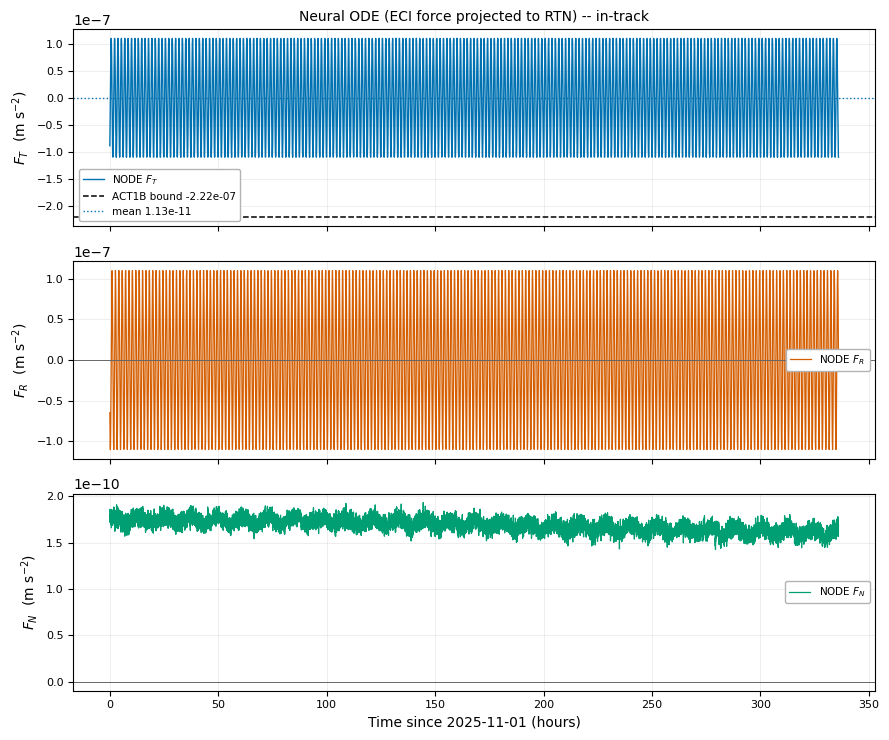

In [ ]:
"""
GRACE-FO Neural ODE baseline -- v2, matched to the inverse PINN

The dynamics are unconstrainted, acting as a baseline for comparison against the inverse PINN
(gracefo_inverse_pinn.ipynb). Every setting that is not the deliberate
experimental difference has been matched to the iPINN for an equal comparison.

 1. 14-DAY ARC, with the same sort/dedup and
    the same cached ECEF->ECI transform file, so both models see identical
    state data.

 2. FLOAT64. Originally ran in float32, whose epsilon (1.19e-7) is LARGER than the
    ratio of the nongravitational force (~3e-7 m/s^2) to gravity (~8.5
    m/s^2, i.e. ~4e-8 relative). In float32 the force is rounded away when
    added to gravity. This is a hard precision wall, not a tuning issue.

 3. MATCHED NONDIMENSIONALIZATION. originally had L0 = 7.0e6; the iPINN uses
    6835624.8 (the row-0 radius). Different L0 changes T0, V0 and every
    derived scale, so the two models' internal quantities were not
    comparable. Now identical.

 4. NORMALIZED TIME INTO THE FOURIER FEATURES. The original version fed raw
    nondimensional time (0..~1300) into features with scale 1.0, producing
    phases of order 10^4 and aliasing the embedding into noise- the network could
    not represent any coherent function of time. This is the same bug that was
    found and fixed in the iPINN. Input is now normalized to [-1, 1].

 5. PHYSICALLY MEANINGFUL TRAINING WINDOWS. v1 fitted 20-step (20 second)
    windows. Over 20 s a 1e-7 m/s^2 force displaces the orbit by ~20
    microns, far below GPS noise (~2 cm) . The force was unobservable by
    construction. Windows are now WINDOW_SEC = 7200 s (~1.3 revolutions),
    over which the same force produces ~2.6 m of displacement, giving a
    workable signal-to-noise ratio. Windows are batched and integrated
    together.

 6. FORCE REPORTED IN RTN.  The network still LEARNS in ECI, which is the
    deliberate difference from the iPINN, which has RTN structure built in.
    But the output is now projected into RTN using the measured r and v
    before any decomposition is reported.

 7. OUTPUT BOUND RAISED. U_TARGET_DIM 2.0e-7 -> 3.0e-6, matching the iPINN.
    The old bound sat below the magnitudes actually recovered, so the tanh
    saturated and gradients vanished.

 8. ORBITAL-FREQUENCY CAPACITY. A drag force is nearly constant in RTN but
    ROTATES ONCE PER REVOLUTION in ECI. Representing it therefore needs
    ~215 cycles across a 14-day arc, versus ~20 for the iPINN's RTN
    parameterization. fourier_scale is set accordingly. This is the intrinsic
    cost of working without frame structure, and the point of the comparison.

 9. MC DROPOUT for uncertainty, matching the iPINN's treatment.


Both models retain the same analytic J2-J5 gravity inside their differential
equation, so gravity fidelity is NOT the variable under test here.
"""

import math
import os
import time
from glob import glob

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torchdiffeq import odeint

from astropy.utils import iers
iers.conf.auto_download = False
iers.conf.auto_max_age = None
from astropy.time import Time
from astropy.coordinates import (
    ITRS, GCRS, CartesianDifferential, CartesianRepresentation)
import astropy.units as u


class CFG:
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    DTYPE  = torch.float64          # see note (2)

    # data
    DATA_FOLDER_PATH = "data"
    FILE_PATTERN     = "GNV1B_2025-11-*_C_04.txt"
    SKIP_ROWS_COUNT  = 148
    COLUMNS_TO_USE   = [0, 3, 4, 5, 9, 10, 11]
    CACHE_ECI        = True

    # constants and scaling
    R_EARTH  = 6378137.0
    MU_EARTH = 3.986004418e14
    J2 =  1.08262668e-3
    J3 = -2.53265649e-6
    J4 = -1.61962159e-6
    J5 = -2.27296083e-7

    L0 = 6835624.8
    T0 = math.sqrt(L0**3 / MU_EARTH)
    V0 = L0 / T0

    U_TARGET_DIM = 3.0e-6
    U_TARGET_ND  = None             # set below

    # ACT1B along-track reference, arc mean 2025-11-01..14, RTN-T convention.
    # LOWER BOUND on |drag| (ACT1B is not bias-calibrated). See
    # act1b_reference.py. Reporting purposes only, never enters a loss!!
    ACT1B_FT_REFERENCE = -2.2183e-7

    # ---- network -----------------------------------------------------------
    hidden          = 128
    depth           = 5
    n_fourier       = 128
    # ECI force rotates once per revolution => ~215 cycles over 14 days.
    fourier_scale   = 250.0
    dropout_p       = 0.05
    mc_samples      = 30

    # training
    N_data_sample = 20000           # matches the iPINN's subsampling
    WINDOW_SEC    = 7200.0          # ~1.3 revolutions; see note (5)
    WINDOW_DT     = 120.0           # sampling within a window
    BATCH_WINDOWS = 16
    epochs        = 1500
    lr            = 1e-3
    ode_method    = 'dopri5'
    ode_rtol      = 1e-8
    ode_atol      = 1e-10

    USE_DRAG_PROXY = False          # see the note in the module docstring


CFG.U_TARGET_ND = CFG.U_TARGET_DIM * (CFG.T0**2 / CFG.L0)

print(f"[CFG] device={CFG.device}  dtype=float64")
print(f"[CFG] window={CFG.WINDOW_SEC:.0f}s ({CFG.WINDOW_SEC/(2*math.pi*CFG.T0):.2f} rev)  "
      f"batch={CFG.BATCH_WINDOWS}  epochs={CFG.epochs}")
print(f"[CFG] force frame = ECI (no RTN structure -- the deliberate difference)")
print(f"[CFG] drag proxy (-k*v): {'ON' if CFG.USE_DRAG_PROXY else 'OFF (matches iPINN antivelocity=False)'}")



# DATA, identical pipeline to the iPINN, sharing the same ECI cache

def ecef_state_to_eci(r_ecef, v_ecef, times):
    rep = CartesianRepresentation(
        r_ecef[:, 0] * u.m, r_ecef[:, 1] * u.m, r_ecef[:, 2] * u.m)
    dif = CartesianDifferential(
        v_ecef[:, 0] * u.m / u.s, v_ecef[:, 1] * u.m / u.s, v_ecef[:, 2] * u.m / u.s)
    itrs = ITRS(rep.with_differentials({'s': dif}), obstime=times)
    gcrs = itrs.transform_to(GCRS(obstime=times))
    return (gcrs.cartesian.xyz.to(u.m).value.T,
            gcrs.cartesian.differentials['s'].d_xyz.to(u.m / u.s).value.T)


def load_gnv1b():
    files = sorted(glob(os.path.join(CFG.DATA_FOLDER_PATH, CFG.FILE_PATTERN)))
    if not files:
        raise FileNotFoundError(f"No files: {CFG.FILE_PATTERN}")
    print(f"Loading {len(files)} file(s)...")

    frames = []
    for f in files:
        df = pd.read_csv(f, skiprows=CFG.SKIP_ROWS_COUNT, sep=r'\s+', header=None,
                         usecols=CFG.COLUMNS_TO_USE, dtype=np.float64, engine='python')
        frames.append(df.values)
        print(f"  {os.path.basename(f)}  ({len(df)} rows)")

    raw = np.concatenate(frames, axis=0)
    raw = raw[np.argsort(raw[:, 0])]
    _, uniq = np.unique(raw[:, 0], return_index=True)
    raw = raw[uniq]

    t_gps, r_ecef, v_ecef = raw[:, 0], raw[:, 1:4], raw[:, 4:7]
    print(f"  {len(t_gps)} samples | arc {(t_gps[-1]-t_gps[0])/86400:.2f} days")

    # Same cache file the iPINN writes -- guarantees identical state data.
    cache = os.path.join(CFG.DATA_FOLDER_PATH, f'_eci_cache_{len(t_gps)}.npz')
    if CFG.CACHE_ECI and os.path.exists(cache):
        print(f"  Loading cached ECI transform: {cache}")
        c = np.load(cache)
        r_eci, v_eci = c['r_eci'], c['v_eci']
    else:
        print("  ECEF->ECI (astropy, one-time)...")
        t0 = time.time()
        times = Time(t_gps[0], format='gps', scale='utc') + (t_gps - t_gps[0]) * u.s
        r_eci, v_eci = ecef_state_to_eci(r_ecef, v_ecef, times)
        print(f"    done in {time.time()-t0:.1f}s")
        if CFG.CACHE_ECI:
            np.savez(cache, r_eci=r_eci, v_eci=v_eci)
    return t_gps, r_eci, v_eci



# MODEL

class FourierFeat(nn.Module):
    def __init__(self, out_f, scale):
        super().__init__()
        self.register_buffer('B', torch.randn(1, out_f // 2) * scale)

    def forward(self, x):
        p = 2 * math.pi * x @ self.B
        return torch.cat([torch.sin(p), torch.cos(p)], dim=-1)


class ForceNet(nn.Module):
    """t -> residual nongravitational acceleration, in ECI.

    Time is normalized to [-1, 1] over the arc before the Fourier embedding
    (see note 4): feeding raw nondimensional time aliased the features into
    noise."""
    def __init__(self, t_arc_nd):
        super().__init__()
        self.register_buffer('t_scale', torch.tensor(float(t_arc_nd)))
        self.fourier = FourierFeat(CFG.n_fourier, CFG.fourier_scale)
        n_out = 4 if CFG.USE_DRAG_PROXY else 3
        layers = [nn.Linear(CFG.n_fourier, CFG.hidden), nn.SiLU(),
                  nn.Dropout(CFG.dropout_p)]
        for _ in range(CFG.depth - 1):
            layers += [nn.Linear(CFG.hidden, CFG.hidden), nn.SiLU(),
                       nn.Dropout(CFG.dropout_p)]
        layers += [nn.Linear(CFG.hidden, n_out)]
        self.net = nn.Sequential(*layers)
        nn.init.normal_(self.net[-1].weight, std=1e-4)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, t):
        h = self.net(self.fourier(2.0 * t / self.t_scale - 1.0))
        u = torch.tanh(h[:, :3]) * CFG.U_TARGET_ND
        k = torch.nn.functional.softplus(h[:, 3:4]) if CFG.USE_DRAG_PROXY else None
        return u, k


def gravity_j2_to_j5(pos_nd):
    """Analytic J2-J5, nondimensional -- the SAME expression used inside the
    iPINN's differential-equation residual, so gravity fidelity is not the
    variable under test."""
    x = pos_nd[:, 0:1]; y = pos_nd[:, 1:2]; z = pos_nd[:, 2:3]
    r = torch.norm(pos_nd, dim=1, keepdim=True)
    r2 = r**2; r4 = r**4; r5 = r**5; r7 = r**7
    Re = CFG.R_EARTH / CFG.L0
    Re2, Re3, Re4, Re5 = Re**2, Re**3, Re**4, Re**5
    z2 = z**2; z4 = z2**2; rxy2 = x**2 + y**2

    a = -pos_nd / (r**3 + 1e-30)
    c2 = 1.5 * CFG.J2 * Re2 / r5
    a = a + c2 * torch.cat([x*(5*z2/r2-1), y*(5*z2/r2-1), z*(5*z2/r2-3)], dim=1)
    a = a + torch.cat([
        CFG.J3*Re3/r7*2.5*x*z*(7*z2/r2-3),
        CFG.J3*Re3/r7*2.5*y*z*(7*z2/r2-3),
        CFG.J3*Re3/r7*2.5*(6*z2*rxy2/r2 - 3*rxy2 - 6*z4/r2 + 3*z2)], dim=1)
    a = a + torch.cat([
        CFG.J4*Re4/r7*(5/8)*x*(3 - 42*z2/r2 + 63*z4/r4),
        CFG.J4*Re4/r7*(5/8)*y*(3 - 42*z2/r2 + 63*z4/r4),
        CFG.J4*Re4/r7*(5/8)*z*(15 - 70*z2/r2 + 63*z4/r4)], dim=1)
    a = a + torch.cat([
        CFG.J5*Re5/r**9*(3/8)*x*z*(35 - 210*z2/r2 + 231*z4/r4),
        CFG.J5*Re5/r**9*(3/8)*y*z*(35 - 210*z2/r2 + 231*z4/r4),
        CFG.J5*Re5/r**9*((15/8)*rxy2*z*(7 - 21*z2/r2)
                         - (3/8)*z*(35*z4/r4 - 30*z2/r2 + 3)*r2) / r2], dim=1)
    return a


class ODEFunc(nn.Module):
    """dy/dt = [v, a_grav + u(t)].  t_offset lets a BATCH of windows starting
    at different absolute times share one local time grid."""
    def __init__(self, force_net):
        super().__init__()
        self.force_net = force_net
        self.t_offset = None        # (B,1) absolute nondim start times

    def forward(self, t, y):
        pos, vel = y[:, :3], y[:, 3:]
        t_abs = self.t_offset + t
        u, k = self.force_net(t_abs)
        a = gravity_j2_to_j5(pos) + u
        if k is not None:
            a = a - k * vel
        return torch.cat([vel, a], dim=1)


def eci_to_rtn_np(vec, r, v):
    R_hat = r / np.linalg.norm(r, axis=1, keepdims=True)
    N_hat = np.cross(r, v); N_hat /= np.linalg.norm(N_hat, axis=1, keepdims=True)
    T_hat = np.cross(N_hat, R_hat)
    return np.stack([np.sum(vec*R_hat, axis=1),
                     np.sum(vec*T_hat, axis=1),
                     np.sum(vec*N_hat, axis=1)], axis=1)



# TRAIN

def train():
    torch.manual_seed(42); np.random.seed(42)
    t0_wall = time.time()

    t_gps, r_eci, v_eci = load_gnv1b()

    t_nd = (t_gps - t_gps[0]) / CFG.T0
    Y_nd = np.hstack((r_eci / CFG.L0, v_eci / CFG.V0))
    T_arc_nd = t_nd[-1] - t_nd[0]

    # full-resolution tensors for window extraction
    T_all = torch.tensor(t_nd, dtype=CFG.DTYPE, device=CFG.device)
    Y_all = torch.tensor(Y_nd, dtype=CFG.DTYPE, device=CFG.device)

    # subsampled grid for inference/reporting -- same count as the iPINN
    idx_rep = np.round(np.linspace(0, len(t_nd)-1, CFG.N_data_sample)).astype(int)

    dt_data   = float(np.median(np.diff(t_gps)))
    win_n     = int(round(CFG.WINDOW_SEC / CFG.WINDOW_DT)) + 1
    win_stride = int(round(CFG.WINDOW_DT / dt_data))
    win_span  = (win_n - 1) * win_stride

    force_net = ForceNet(T_arc_nd).to(CFG.device, dtype=CFG.DTYPE)
    ode_func  = ODEFunc(force_net).to(CFG.device, dtype=CFG.DTYPE)
    opt = optim.AdamW(force_net.parameters(), lr=CFG.lr)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, CFG.epochs)

    print("\n" + "=" * 70)
    print("NEURAL ODE v2 -- matched to the inverse PINN")
    print(f"window {win_n} pts @ {CFG.WINDOW_DT:.0f}s  |  batch {CFG.BATCH_WINDOWS}  "
          f"|  {CFG.epochs} epochs")
    print("=" * 70)

    t_local = torch.arange(win_n, dtype=CFG.DTYPE, device=CFG.device) \
              * (CFG.WINDOW_DT / CFG.T0)

    for ep in range(CFG.epochs):
        opt.zero_grad()
        starts = np.random.randint(0, len(T_all) - win_span - 1, CFG.BATCH_WINDOWS)
        sel = np.stack([np.arange(s, s + win_span + 1, win_stride) for s in starts])
        y_true = Y_all[torch.tensor(sel, device=CFG.device)]          # (B, n, 6)
        ode_func.t_offset = T_all[torch.tensor(starts, device=CFG.device)].unsqueeze(1)

        y_pred = odeint(ode_func, y_true[:, 0, :], t_local,
                        method=CFG.ode_method, rtol=CFG.ode_rtol, atol=CFG.ode_atol)
        y_pred = y_pred.permute(1, 0, 2)                              # (B, n, 6)

        loss = torch.mean((y_pred - y_true) ** 2)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(force_net.parameters(), 1.0)
        opt.step(); sched.step()

        if ep % 100 == 0:
            with torch.no_grad():
                u_probe, _ = force_net(T_all[idx_rep[:2000]].unsqueeze(1))
                mag = (torch.norm(u_probe, dim=1).mean() * CFG.L0/CFG.T0**2).item()
            print(f"  ep {ep:5d}: state_loss={loss.item():.4e}  mean|u|={mag:.3e} m/s^2")

    print(f"[time] training: {time.time()-t0_wall:.1f}s")

    # MC-dropout inference, then project ECI -> RTN
    print(f"\nMC inference ({CFG.mc_samples} samples)...")
    t_rep = T_all[idx_rep].unsqueeze(1)
    force_net.train()                       # dropout on for MC
    with torch.no_grad():
        s = torch.stack([force_net(t_rep)[0] for _ in range(CFG.mc_samples)], 0)
    u_mean = (s.mean(0) * (CFG.L0/CFG.T0**2)).cpu().numpy()
    u_std  = (s.std(0)  * (CFG.L0/CFG.T0**2)).cpu().numpy()

    r_rep, v_rep = r_eci[idx_rep], v_eci[idx_rep]
    rtn      = eci_to_rtn_np(u_mean, r_rep, v_rep)
    rtn_std  = eci_to_rtn_np(u_std,  r_rep, v_rep)
    Fr, Ft, Fn = rtn[:, 0], rtn[:, 1], rtn[:, 2]
    t_hrs = (t_gps[idx_rep] - t_gps[0]) / 3600.0

    #  report
    rms_r, rms_t, rms_n = (np.sqrt(np.mean(Fr**2)), np.sqrt(np.mean(Ft**2)),
                           np.sqrt(np.mean(Fn**2)))
    tot = rms_r**2 + rms_t**2 + rms_n**2 + 1e-30
    ref = CFG.ACT1B_FT_REFERENCE

    print("\n" + "=" * 70)
    print("NEURAL ODE -- RTN force decomposition  (force learned in ECI,")
    print("               projected to RTN with the measured r, v)")
    print("=" * 70)
    print(f"  mean Fr (radial)     : {Fr.mean():+.4e} m/s^2")
    print(f"  mean Ft (in-track)   : {Ft.mean():+.4e} m/s^2   "
          f"ratio {Ft.mean()/ref:.3f} vs ACT1B bound {ref:.3e}")
    print(f"  mean Fn (cross-track): {Fn.mean():+.4e} m/s^2")
    print(f"  RMS  Fr={rms_r:.3e}  Ft={rms_t:.3e}  Fn={rms_n:.3e}  m/s^2")
    print(f"  energy fraction  radial={rms_r**2/tot:.3f}  "
          f"in-track={rms_t**2/tot:.3f}  cross={rms_n**2/tot:.3f}")
    print(f"  SNR (in-track)       : {abs(Ft.mean())/(np.mean(np.abs(rtn_std[:,1]))+1e-30):.1f}")
    print(f"  drag proxy           : {'ON' if CFG.USE_DRAG_PROXY else 'OFF'}")
    print("=" * 70)

    #  plot
    plt.style.use('default')
    C_T, C_R, C_N = '#0072B2', '#D55E00', '#009E73'
    fig, ax = plt.subplots(3, 1, figsize=(9, 7.5), sharex=True)
    fig.patch.set_facecolor('white')

    ax[0].plot(t_hrs, Ft, color=C_T, lw=1.0, label='NODE $F_T$')
    ax[0].axhline(ref, color='k', ls='--', lw=1.1, label=f'ACT1B bound {ref:.2e}')
    ax[0].axhline(Ft.mean(), color=C_T, ls=':', lw=1.0, label=f'mean {Ft.mean():.2e}')
    ax[0].set_ylabel('$F_T$  (m s$^{-2}$)')
    ax[0].legend(fontsize=7.5, framealpha=1.0, edgecolor='0.7')
    ax[0].set_title('Neural ODE (ECI force projected to RTN) -- in-track', fontsize=10)

    ax[1].plot(t_hrs, Fr, color=C_R, lw=0.9, label='NODE $F_R$')
    ax[1].axhline(0, color='0.4', lw=0.7)
    ax[1].set_ylabel('$F_R$  (m s$^{-2}$)')
    ax[1].legend(fontsize=7.5, framealpha=1.0, edgecolor='0.7')

    ax[2].plot(t_hrs, Fn, color=C_N, lw=0.9, label='NODE $F_N$')
    ax[2].axhline(0, color='0.4', lw=0.7)
    ax[2].set_ylabel('$F_N$  (m s$^{-2}$)')
    ax[2].set_xlabel('Time since 2025-11-01 (hours)')
    ax[2].legend(fontsize=7.5, framealpha=1.0, edgecolor='0.7')

    for a in ax:
        a.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
        a.grid(alpha=0.3, lw=0.5); a.tick_params(labelsize=8)
        for sp in a.spines.values():
            sp.set_linewidth(0.8)
    fig.tight_layout()
    out = os.path.join(CFG.DATA_FOLDER_PATH, 'neural_ode_v2.png')
    fig.savefig(out, dpi=300, facecolor='white', bbox_inches='tight')
    print(f"Saved plot: {out}")

    # save, RTN-named so it can't be confused with ECI
    for nm, arr in (('time', t_hrs), ('Fr', Fr), ('Ft', Ft), ('Fn', Fn),
                    ('Ft_std', rtn_std[:, 1])):
        np.save(os.path.join(CFG.DATA_FOLDER_PATH, f'node_v2_{nm}.npy'), arr)
    print("Saved arrays with prefix node_v2_  (RTN components)")
    print(f"[time] TOTAL: {time.time()-t0_wall:.1f}s")


if __name__ == '__main__':
    train()

Neural ODE  (node_v2)  --  20000 samples, 336.0 h arc
  mean Fr (radial)       : +5.5124e-11   RMS 7.784e-08 m/s^2
  mean Ft (in-track)     : +1.1334e-11   RMS 7.780e-08 m/s^2
  mean Fn (cross-track)  : +1.6915e-10   RMS 1.693e-10 m/s^2
  energy fraction  radial=0.500  in-track=0.500  cross=0.000
  ratio of mean Ft to ACT1B bound (-2.218e-07): -0.000
  rendering: per-revolution envelope + detail
Saved: /content/drive/MyDrive/science_fair/GRACEFO_Nov2025/forces_node_v2.png


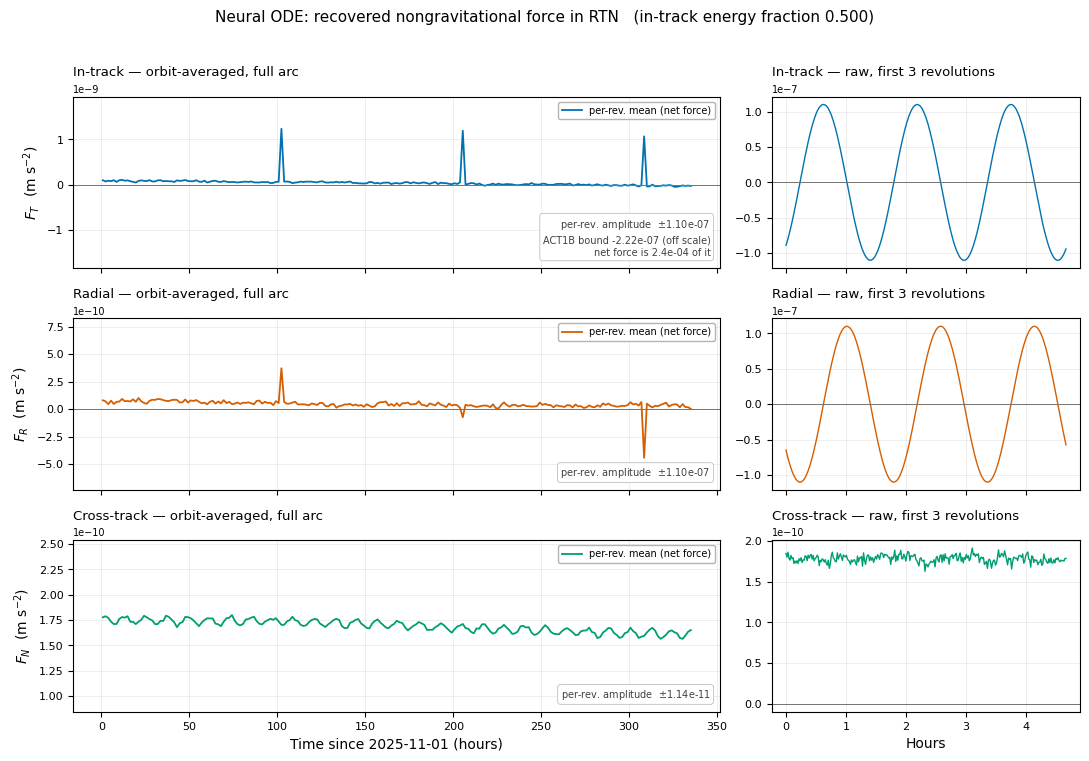

In [ ]:
"""
plot_forces.py -- standalone publication figures from saved force arrays
=========================================================================
Regenerates the RTN force figure for either model from its saved .npy
arrays, without retraining. Useful because the Neural ODE takes ~2.8 h and
the inverse PINN ~29 min, and figure styling should not cost a training run.

It also recomputes and prints the summary statistics, so the figure can be
checked against the numbers the training run reported.

Set CFG.PREFIX to the saved-array prefix:
    'v7_full'   -> inverse PINN   (also v7_no_gravity, v7_no_rtn, ...)
    'node_v2'   -> Neural ODE

ENVELOPE RENDERING
------------------
A force expressed in RTN that is genuinely drag-like is nearly constant, and
plots cleanly as a line. A force learned in ECI oscillates once per
revolution, so ~215 cycles land inside a 336-hour axis and a raw line
renders as a solid block.

For the oscillatory case each component is drawn twice: a per-revolution
min/max envelope with the orbit-averaged mean over the full arc, and an
unsmoothed 3-revolution detail window. The envelope bounds the true
excursion exactly -- nothing is hidden by smoothing, and the per-revolution
mean makes the net force visible, which is the quantity that matters.

CFG.ENVELOPE = 'auto' decides by comparing the scatter of per-revolution
means against the scatter of the raw samples: if the signal varies mostly
WITHIN revolutions rather than across them, the envelope is used.
"""

import os
import math

import numpy as np
import matplotlib.pyplot as plt

CFG.PREFIX = 'node_v2'   # Neural ODE  -> forces_node_v2.png
CFG.PREFIX = 'v7_full'   # inverse PINN -> forces_v7_full.png
class CFG:
    DATA_FOLDER = "/content/drive/MyDrive/science_fair/GRACEFO_Nov2025"

    PREFIX = 'node_v2'          # 'node_v2' | 'v7_full' | 'v7_no_rtn' | ...
    LABEL  = None               # None -> inferred from PREFIX

    ENVELOPE = 'auto'           # True | False | 'auto'
    ZOOM_REVS = 3               # revolutions in the detail panel

    ORBIT_SEC = 5624.0          # GRACE-FO revolution (2*pi*T0)

    # ACT1B along-track reference, arc mean 2025-11-01..14, RTN-T convention.
    # LOWER BOUND on |drag| -- ACT1B is not bias-calibrated. Reporting only.
    ACT1B_FT_REFERENCE = -2.2183e-7


_NICE = {'node_v2': 'Neural ODE', 'v7_full': 'Inverse PINN'}


def load(prefix):
    def p(n):
        return os.path.join(CFG.DATA_FOLDER, f'{prefix}_{n}.npy')
    need = ('time', 'Fr', 'Ft', 'Fn')
    missing = [n for n in need if not os.path.exists(p(n))]
    if missing:
        raise FileNotFoundError(
            f"Missing {[os.path.basename(p(n)) for n in missing]} -- "
            f"run the model first so it writes {prefix}_*.npy")
    t = np.load(p('time'))                       # hours since arc start
    Fr, Ft, Fn = (np.load(p(n)) for n in ('Fr', 'Ft', 'Fn'))
    std = np.load(p('Ft_std')) if os.path.exists(p('Ft_std')) else None
    order = np.argsort(t)
    return (t[order], Fr[order], Ft[order], Fn[order],
            None if std is None else std[order])


def envelope(t, y, per_hr):
    """Chunk into bins of EXACTLY per_hr -> (centres, min, max, mean).

    Bin edges must be exact multiples of the averaging period. Using
    linspace across the arc instead gives bins of arc/n, which for a
    336 h arc and a 1.5622 h revolution is 1.5628 h -- a 0.0006 h/bin
    mismatch that accumulates to ~8% of a revolution over the arc. The
    per-revolution mean of a sinusoid is sensitive to bin phase, so that
    drift injects a slow spurious wobble (visible as periodic spikes) into
    what should be a flat line. Any trailing partial bin is dropped, since
    a partial revolution does not average to the same thing."""
    span = t[-1] - t[0]
    nb = max(2, int(span // per_hr))
    edges = t[0] + np.arange(nb + 1) * per_hr
    idx = np.searchsorted(edges, t, 'right') - 1
    keep = (idx >= 0) & (idx < nb)
    idx, yv = idx[keep], y[keep]
    c = 0.5 * (edges[:-1] + edges[1:])
    lo = np.full(nb, np.nan); hi = np.full(nb, np.nan); mu = np.full(nb, np.nan)
    for b in range(nb):
        m = idx == b
        if m.any():
            lo[b], hi[b], mu[b] = yv[m].min(), yv[m].max(), yv[m].mean()
    ok = ~np.isnan(mu)
    return c[ok], lo[ok], hi[ok], mu[ok]


def needs_envelope(t, comps, per_hr):
    """True when the signal varies mostly WITHIN revolutions rather than
    across them -- i.e. a line plot would collapse into a block."""
    ratios = []
    for y in comps:
        if y.std() <= 0:
            continue
        _, _, _, mu = envelope(t, y, per_hr)
        ratios.append(mu.std() / y.std())
    return bool(ratios) and float(np.median(ratios)) < 0.30


def main():
    label = CFG.LABEL or _NICE.get(CFG.PREFIX, CFG.PREFIX)
    t_hr, Fr, Ft, Fn, Ft_std = load(CFG.PREFIX)
    orbit_hr = CFG.ORBIT_SEC / 3600.0
    ref = CFG.ACT1B_FT_REFERENCE

    # ---- statistics (verify against the training run's printout) --------
    rms = [float(np.sqrt(np.mean(c**2))) for c in (Fr, Ft, Fn)]
    tot = sum(r**2 for r in rms) + 1e-30
    print("=" * 70)
    print(f"{label}  ({CFG.PREFIX})  --  {len(t_hr)} samples, "
          f"{t_hr[-1]-t_hr[0]:.1f} h arc")
    print("=" * 70)
    for nm, c, r in zip(('Fr (radial)', 'Ft (in-track)', 'Fn (cross-track)'),
                        (Fr, Ft, Fn), rms):
        print(f"  mean {nm:<18}: {c.mean():+.4e}   RMS {r:.3e} m/s^2")
    print(f"  energy fraction  radial={rms[0]**2/tot:.3f}  "
          f"in-track={rms[1]**2/tot:.3f}  cross={rms[2]**2/tot:.3f}")
    print(f"  ratio of mean Ft to ACT1B bound ({ref:.3e}): {Ft.mean()/ref:.3f}")

    use_env = (needs_envelope(t_hr, (Fr, Ft, Fn), orbit_hr)
               if CFG.ENVELOPE == 'auto' else bool(CFG.ENVELOPE))
    print(f"  rendering: {'per-revolution envelope + detail' if use_env else 'direct line'}")
    print("=" * 70)

    plt.style.use('default')
    C_T, C_R, C_N = '#0072B2', '#D55E00', '#009E73'
    panels = [(Ft, C_T, '$F_T$', 'In-track'),
              (Fr, C_R, '$F_R$', 'Radial'),
              (Fn, C_N, '$F_N$', 'Cross-track')]

    if use_env:
        # Full-arc panel shows the PER-REVOLUTION MEAN, not a min/max band.
        # For a force that oscillates at constant amplitude the band is a
        # constant-width slab -- it fills the axis, conveys one number, and
        # hides the quantity that actually matters, which is the net (orbit-
        # averaged) force. The amplitude is reported as an annotation
        # instead, so nothing is lost. The detail panel on the right still
        # shows the raw unsmoothed oscillation.
        fig, axes = plt.subplots(3, 2, figsize=(11, 7.6), sharex='col',
                                 gridspec_kw={'width_ratios': [2.1, 1.0]})
        zoom = t_hr <= CFG.ZOOM_REVS * orbit_hr
        for i, (y, c, sym, name) in enumerate(panels):
            aL, aR = axes[i, 0], axes[i, 1]
            ct, lo, hi, mu = envelope(t_hr, y, orbit_hr)
            amp = 0.5 * float(np.mean(hi - lo))

            aL.plot(ct, mu, color=c, lw=1.3, label='per-rev. mean (net force)')
            aL.axhline(0, color='0.45', lw=0.7)

            # Every panel scales to its OWN data. Forcing the ACT1B bound onto
            # the in-track axis does not work when the two differ by four
            # orders of magnitude: the recovered mean gets pinned to the axis
            # line and becomes invisible. The comparison is stated numerically
            # in the annotation instead, which is both readable and more
            # precise than a squashed axis.
            pad = max(mu.std() * 4.0, abs(mu - mu.mean()).max() * 1.6,
                      abs(mu.mean()) * 0.5, 1e-30)
            aL.set_ylim(mu.mean() - pad, mu.mean() + pad)

            note = f'per-rev. amplitude  $\\pm${amp:.2e}'
            if i == 0:
                frac = abs(mu.mean() / ref) if ref else float('nan')
                note += (f'\nACT1B bound {ref:.2e} (off scale)\n'
                         f'net force is {frac:.1e} of it')
            aL.text(0.985, 0.06, note,
                    transform=aL.transAxes, ha='right', va='bottom', fontsize=7,
                    color='0.25', linespacing=1.35,
                    bbox=dict(boxstyle='round,pad=0.3', fc='white',
                              ec='0.75', lw=0.6))
            aL.set_ylabel(f'{sym}  (m s$^{{-2}}$)')
            aL.legend(fontsize=7, framealpha=1.0, edgecolor='0.7', loc='upper right')
            aL.set_title(f'{name} — orbit-averaged, full arc',
                         fontsize=9.5, loc='left')

            aR.plot(t_hr[zoom], y[zoom], color=c, lw=1.0)
            aR.axhline(0, color='0.45', lw=0.7)
            aR.set_title(f'{name} — raw, first {CFG.ZOOM_REVS} revolutions',
                         fontsize=9.5, loc='left')
        axes[2, 0].set_xlabel('Time since 2025-11-01 (hours)')
        axes[2, 1].set_xlabel('Hours')
        flat = axes.ravel()
    else:
        fig, axes = plt.subplots(3, 1, figsize=(9, 7.5), sharex=True)
        for i, (y, c, sym, name) in enumerate(panels):
            a = axes[i]
            if i == 0 and Ft_std is not None:
                a.fill_between(t_hr, y - Ft_std, y + Ft_std, color=c,
                               alpha=0.25, lw=0, label='$\\pm1\\sigma$ (MC dropout)')
            a.plot(t_hr, y, color=c, lw=1.1, label=f'{sym}')
            a.axhline(0, color='0.45', lw=0.7)
            if i == 0:
                a.axhline(ref, color='k', ls='--', lw=1.1,
                          label=f'ACT1B bound {ref:.2e}')
                a.axhline(y.mean(), color=c, ls=':', lw=1.0,
                          label=f'mean {y.mean():.2e}')
            a.set_ylabel(f'{sym}  (m s$^{{-2}}$)')
            a.legend(fontsize=7.5, framealpha=1.0, edgecolor='0.7')
            a.set_title(name, fontsize=9.5, loc='left')
        axes[-1].set_xlabel('Time since 2025-11-01 (hours)')
        flat = axes

    for a in flat:
        a.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
        a.grid(alpha=0.3, lw=0.5); a.tick_params(labelsize=8)
        a.yaxis.get_offset_text().set_size(7)
        for sp in a.spines.values():
            sp.set_linewidth(0.8)

    fig.suptitle(f'{label}: recovered nongravitational force in RTN   '
                 f'(in-track energy fraction {rms[1]**2/tot:.3f})',
                 fontsize=11, y=0.995)
    fig.tight_layout(rect=[0, 0, 1, 0.98])
    out = os.path.join(CFG.DATA_FOLDER, f'forces_{CFG.PREFIX}.png')
    fig.savefig(out, dpi=300, facecolor='white', bbox_inches='tight')
    print(f"Saved: {out}")


if __name__ == '__main__':
    main()